### Test

In [107]:
print("Hello World")

Hello World


### Initial Analysis

In [108]:
import pandas as pd

In [109]:
dataset = pd.read_csv("../data/messy_ml_data.csv")
dataset.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode,DiscountCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04,NaN
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04,NaN
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02,SAVE10


In [110]:
dataset.shape

(761, 14)

In [111]:
dataset.isnull().sum().sum()*100/(dataset.shape[0]*dataset.shape[1])

np.float64(6.711094424629247)

In [112]:
dataset.notnull().sum().sum()

np.int64(9939)

In [113]:
(dataset.isnull().sum()/dataset.shape[0])*100

PassengerId      0.000000
Age              2.102497
Fare             3.285151
Gender           3.022339
City             2.759527
Subscription     3.416557
Score            2.102497
JoinDate         2.628121
Email            1.576873
Phone            3.416557
IsActive         2.759527
Remarks          3.416557
DeptCode         2.759527
DiscountCode    60.709593
dtype: float64

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

### Plotting all the null values

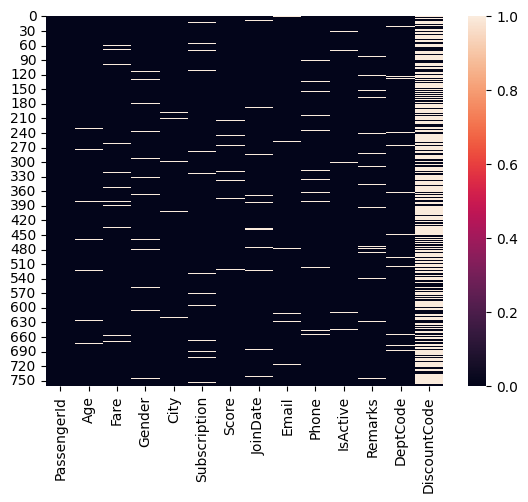

In [115]:
sns.heatmap(dataset.isnull())
plt.show()

### Removed all null values in the PassengerId column using AI

In [116]:
df = pd.read_csv('../data/messy_ml_data.csv')
print(df['PassengerId'].dtype)
print(df['PassengerId'].isnull().sum())

int64
0


### Deleting columns with more than 50% data missing

In [117]:
dataset.drop(columns=["DiscountCode"],inplace=True)

In [118]:
(dataset.isnull().sum()/dataset.shape[0])*100

PassengerId     0.000000
Age             2.102497
Fare            3.285151
Gender          3.022339
City            2.759527
Subscription    3.416557
Score           2.102497
JoinDate        2.628121
Email           1.576873
Phone           3.416557
IsActive        2.759527
Remarks         3.416557
DeptCode        2.759527
dtype: float64

### Deleting rows with null values

In [119]:
dataset.head(2)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
0,1,52.0,104.22,F,Tokyo,Free,55.0,2020-01-01,NaN,+1-555-8540,True,Good,D04
1,2,15.0,30.03,F,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04


In [121]:
dataset.dropna(inplace=True)

In [122]:
(dataset.isnull().sum()/dataset.shape[0])*100

PassengerId     0.0
Age             0.0
Fare            0.0
Gender          0.0
City            0.0
Subscription    0.0
Score           0.0
JoinDate        0.0
Email           0.0
Phone           0.0
IsActive        0.0
Remarks         0.0
DeptCode        0.0
dtype: float64

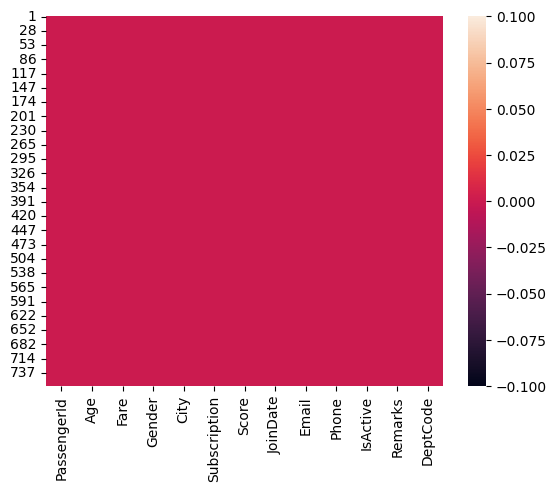

In [123]:
sns.heatmap(dataset.isnull())
plt.show()

In [124]:
dataset.shape

(545, 13)

#### Total data lost in % rows after removing nulls

In [125]:
100*(761-545)/761

28.38370565045992

### Check for duplicates

In [126]:
print(f"Duplicate rows: {dataset.duplicated().sum()}")

Duplicate rows: 0


### Inspect unique values in categorical columns

In [127]:
print(dataset['Gender'].unique())

<StringArray>
['F', 'Female', 'Male', 'M', 'female', 'male']
Length: 6, dtype: str


In [128]:
print(dataset['IsActive'].unique())

<StringArray>
['False', '0', 'Yes', 'True', 'No', '1', 'none']
Length: 7, dtype: str


In [129]:
print(dataset['DeptCode'].unique())

<StringArray>
['D04', 'D02', 'D01', 'D03']
Length: 4, dtype: str


In [148]:
print(dataset['Subscription'].unique())

<StringArray>
['Premium', 'Basic', 'Free', 'FREE', 'NONE', 'BASIC', 'PREMIUM']
Length: 7, dtype: str


In [130]:
dataset['Gender'].str.strip()

1           F
2      Female
3        Male
4           M
6           F
        ...  
756      male
757      male
758         F
759      male
760    Female
Name: Gender, Length: 545, dtype: str

### Fixing Subscription, Gender and IsActive values

In [140]:
gender_map = {
    'F': 'Female',
    'female': 'Female',
    'M': 'Male',
    'male': 'Male'
}

In [133]:
df = dataset

In [134]:
df['Gender'] = df['Gender'].replace(gender_map)

In [135]:
print(df['Gender'].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [136]:
dataset['Gender'] = dataset['Gender'].replace(gender_map)

In [137]:
print(dataset['Gender'].unique())

<StringArray>
['Female', 'Male']
Length: 2, dtype: str


In [143]:
dataset.head(5)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
1,2,15.0,30.03,Female,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,0,Poor,D02
3,4,61.0,146.51,Male,London,Basic,87.0,2020-01-04,user3@example.com,+1-555-9521,Yes,Average,D04
4,5,21.0,96.74,Male,Tokyo,Basic,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01
6,7,75.0,69.11,Female,Berlin,Basic,69.0,2020-01-07,user6@example.com,+1-555-3851,True,Poor,D01


In [145]:
isActive_map = {
    '0': 'False',
    'No': 'False',
    'none': 'False',
    '1': 'True',
    'Yes': 'True'
}

In [146]:
dataset['IsActive'] = dataset['IsActive'].replace(isActive_map)

In [147]:
dataset.head(5)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
1,2,15.0,30.03,Female,London,Premium,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04
2,3,72.0,92.78,Female,New York,Basic,90.0,2020-01-03,user2@example.com,+1-555-3474,False,Poor,D02
3,4,61.0,146.51,Male,London,Basic,87.0,2020-01-04,user3@example.com,+1-555-9521,True,Average,D04
4,5,21.0,96.74,Male,Tokyo,Basic,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01
6,7,75.0,69.11,Female,Berlin,Basic,69.0,2020-01-07,user6@example.com,+1-555-3851,True,Poor,D01


In [150]:
Subscription_map = {
    'Premium': 'PREMIUM',
    'Basic': 'BASIC',
    'none': 'FREE',
    'Free': 'FREE',
    'NONE': 'FREE'
}

In [151]:
dataset['Subscription'] = dataset['Subscription'].replace(Subscription_map)

In [152]:
dataset.head(5)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
1,2,15.0,30.03,Female,London,PREMIUM,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04
2,3,72.0,92.78,Female,New York,BASIC,90.0,2020-01-03,user2@example.com,+1-555-3474,False,Poor,D02
3,4,61.0,146.51,Male,London,BASIC,87.0,2020-01-04,user3@example.com,+1-555-9521,True,Average,D04
4,5,21.0,96.74,Male,Tokyo,BASIC,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01
6,7,75.0,69.11,Female,Berlin,BASIC,69.0,2020-01-07,user6@example.com,+1-555-3851,True,Poor,D01


In [153]:
print(dataset['Subscription'].unique())

<StringArray>
['PREMIUM', 'BASIC', 'FREE']
Length: 3, dtype: str


### Converting Age to int from float

In [154]:
df['Age'] = df['Age'].round().astype('Int64')

In [155]:
df.head(5)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
1,2,15,30.03,Female,London,PREMIUM,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04
2,3,72,92.78,Female,New York,BASIC,90.0,2020-01-03,user2@example.com,+1-555-3474,False,Poor,D02
3,4,61,146.51,Male,London,BASIC,87.0,2020-01-04,user3@example.com,+1-555-9521,True,Average,D04
4,5,21,96.74,Male,Tokyo,BASIC,73.0,2020-01-05,user4@example.com,+1-555-1242,False,Unknown,D01
6,7,75,69.11,Female,Berlin,BASIC,69.0,2020-01-07,user6@example.com,+1-555-3851,True,Poor,D01


In [156]:
dataset['Age'] = dataset['Age'].round().astype('Int64')

In [157]:
dataset.head(3)

,PassengerId,Age,Fare,Gender,City,Subscription,Score,JoinDate,Email,Phone,IsActive,Remarks,DeptCode
1,2,15,30.03,Female,London,PREMIUM,82.0,2020-01-02,user1@example.com,+1-555-6340,False,Average,D04
2,3,72,92.78,Female,New York,BASIC,90.0,2020-01-03,user2@example.com,+1-555-3474,False,Poor,D02
3,4,61,146.51,Male,London,BASIC,87.0,2020-01-04,user3@example.com,+1-555-9521,True,Average,D04
